# Financial News Sentiment Prediction

## Exploratory Data Analysis & Preprocessing

Dataset: Twitter Financial News Sentiment

Goal:
Prepare the dataset for deep learning models (RNN, LSTM, GRU, BERT)

### Import Libraries


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

### Load Dataset

In [3]:
train_df = pd.read_csv("sent_train.csv")
valid_df = pd.read_csv("sent_valid.csv")

### Understanding Dataset

In [4]:
print("Train shape:", train_df.shape)
print("Validation shape:", valid_df.shape)

Train shape: (9543, 2)
Validation shape: (2388, 2)


In [5]:
train_df.head()

,text,label
0,$BYND - JPMorgan reels in expectations on Beyo...,0
1,$CCL $RCL - Nomura points to bookings weakness...,0
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan ...",0
3,$ESS: BTIG Research cuts to Neutral https://t....,0
4,$FNKO - Funko slides after Piper Jaffray PT cu...,0


In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9543 entries, 0 to 9542
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    9543 non-null   object
 1   label   9543 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 149.2+ KB


In [7]:
train_df.isnull().sum()

text     0
label    0
dtype: int64

In [8]:
# Class Distribution

train_df['label'].value_counts()

label
2    6178
1    1923
0    1442
Name: count, dtype: int64

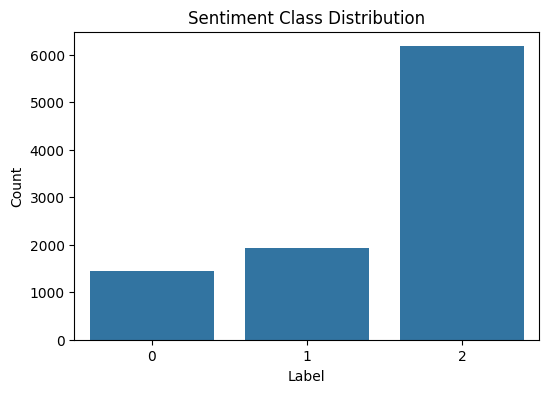

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(x=train_df['label'])

plt.title("Sentiment Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")

plt.show()

### Sentiment Class Distribution Analysis

The dataset shows class imbalance.

Neutral tweets dominate the dataset, with significantly more samples compared to Bearish and Bullish tweets.

Approximate distribution:

Bearish: ~1500  
Bullish: ~1900  
Neutral: ~6200  

Because of this imbalance, accuracy alone may not be a reliable metric.  
Therefore, Macro F1-score will be used to evaluate model performance, ensuring all classes are treated equally.

###  Map Labels to Sentiment

In [10]:
label_map = {
    0: "Bearish",
    1: "Bullish",
    2: "Neutral"
}

train_df['sentiment'] = train_df['label'].map(label_map)

In [11]:
train_df.head()

,text,label,sentiment
0,$BYND - JPMorgan reels in expectations on Beyo...,0,Bearish
1,$CCL $RCL - Nomura points to bookings weakness...,0,Bearish
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan ...",0,Bearish
3,$ESS: BTIG Research cuts to Neutral https://t....,0,Bearish
4,$FNKO - Funko slides after Piper Jaffray PT cu...,0,Bearish


### Tweet Length Analysis

In [12]:
train_df['tweet_length'] = train_df['text'].apply(lambda x: len(x.split()))

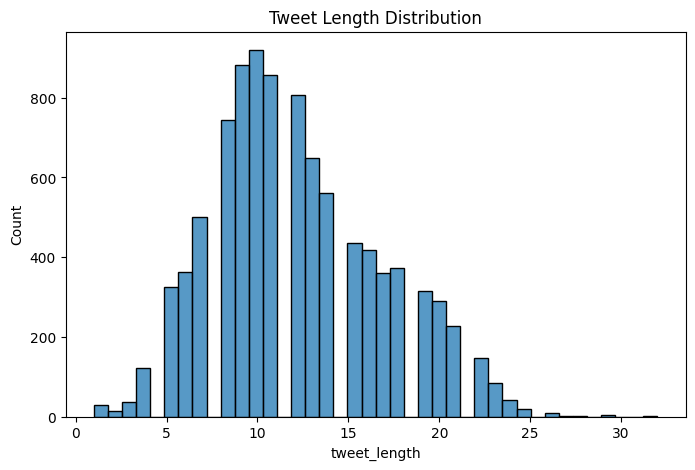

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(train_df['tweet_length'], bins=40)

plt.title("Tweet Length Distribution")

plt.show()

In [14]:
train_df['tweet_length'].describe()

count    9543.000000
mean       12.178351
std         4.665599
min         1.000000
25%         9.000000
50%        11.000000
75%        15.000000
max        32.000000
Name: tweet_length, dtype: float64

The average tweet length is approximately 12 words, with most tweets falling between 9 and 15 words.

The longest tweet in the dataset contains 32 words.

To ensure that nearly all tweets are captured without excessive padding, the maximum sequence length for tokenization is set to **40 tokens**.

### Text Cleaning

In [15]:
def clean_text(text):
    
    text = text.lower()
    
    text = re.sub(r"http\S+", "", text)   # remove URLs
    text = re.sub(r"@\w+", "", text)      # remove mentions
    text = re.sub(r"#", "", text)         # remove hashtags
    
    text = re.sub(r"[^\w\s]", "", text)   # remove punctuation
    
    text = re.sub(r"\s+", " ", text)      # remove extra spaces
    
    return text.strip()

### Apply Cleaning

In [16]:
train_df['clean_text'] = train_df['text'].apply(clean_text)
valid_df['clean_text'] = valid_df['text'].apply(clean_text)

In [17]:
train_df[['text','clean_text']].head()

,text,clean_text
0,$BYND - JPMorgan reels in expectations on Beyo...,bynd jpmorgan reels in expectations on beyond ...
1,$CCL $RCL - Nomura points to bookings weakness...,ccl rcl nomura points to bookings weakness at ...
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan ...",cx cemex cut at credit suisse jp morgan on wea...
3,$ESS: BTIG Research cuts to Neutral https://t....,ess btig research cuts to neutral
4,$FNKO - Funko slides after Piper Jaffray PT cu...,fnko funko slides after piper jaffray pt cut


### Tokenization

In [20]:
from collections import Counter

word_counter = Counter()

for text in train_df['clean_text']:
    word_counter.update(text.split())

# Keep top 10,000 words
vocab_size = 10000
vocab = {word: i+1 for i, (word, _) in enumerate(word_counter.most_common(vocab_size))}

print("Vocabulary size:", len(vocab))

Vocabulary size: 10000


### Convert Text → Sequences

In [21]:
def text_to_sequence(text, vocab):
    return [vocab.get(word, 0) for word in text.split()]


In [22]:
train_sequences = train_df['clean_text'].apply(lambda x: text_to_sequence(x, vocab))
valid_sequences = valid_df['clean_text'].apply(lambda x: text_to_sequence(x, vocab))

In [23]:
train_sequences.iloc[0]

[5081, 804, 5082, 4, 352, 5, 848, 1280]

### Padding Sequences

In [24]:
def pad_sequence(seq, max_length):
    seq = seq[:max_length]
    seq += [0] * (max_length - len(seq))
    return seq

In [26]:
# Apply padding

max_length = 40

X_train = np.array([pad_sequence(seq, max_length) for seq in train_sequences])
X_valid = np.array([pad_sequence(seq, max_length) for seq in valid_sequences])

In [27]:
print(X_train.shape)
print(X_valid.shape)

(9543, 40)
(2388, 40)


### Prepare Labels

In [28]:
y_train = train_df['label'].values
y_valid = valid_df['label'].values

### Save Processed Data

In [29]:
np.save("X_train.npy", X_train)
np.save("X_valid.npy", X_valid)

np.save("y_train.npy", y_train)
np.save("y_valid.npy", y_valid)

In [30]:
import pickle

with open("vocab.pkl", "wb") as f:
    pickle.dump(vocab, f)